In [ ]:
import matplotlib
%matplotlib inline

import _pickle as pickle
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import scipy

from matplotlib.patches import Patch
from tqdm.notebook import tqdm

In [2]:
data_dir = "/Users/chanb/research/ualberta/hint_rl/data/eval-per_hint_percentage"
all_evals = sorted([
    filename for filename in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, filename)) and filename.startswith("local_eval-")
])

In [3]:
all_evals

['local_eval-per_hint_percentage-0',
 'local_eval-per_hint_percentage-10',
 'local_eval-per_hint_percentage-100',
 'local_eval-per_hint_percentage-20',
 'local_eval-per_hint_percentage-30',
 'local_eval-per_hint_percentage-40',
 'local_eval-per_hint_percentage-50',
 'local_eval-per_hint_percentage-60',
 'local_eval-per_hint_percentage-70',
 'local_eval-per_hint_percentage-80',
 'local_eval-per_hint_percentage-90']

In [4]:
all_results = dict()

In [5]:
n_samples = 8
k_sampless = [1, 2, 4, 8]

In [6]:
def pass_k(n_success, n_samples, k_samples):
    pass_k = (
        1 - scipy.special.comb(
            n_samples - n_success,
            k_samples,
            exact=False,
        ) / scipy.special.comb(n_samples, k_samples, exact=False)
    )
    return pass_k

In [7]:
agg_filename = "agg_eval-per_hint_percentage.pkl"
if os.path.isfile(agg_filename):
    all_results = pickle.load(open(agg_filename, "rb"))
else:
    for eval_name in tqdm(all_evals):
        curr_dir = os.path.join(data_dir, eval_name)
        key = eval_name.split("-")[-1]
        all_results.setdefault(key, dict())

        curr_pass_k_results = []
        for sample_filename in os.listdir(os.path.join(curr_dir, "rollout/0")):
            sample_file = os.path.join(curr_dir, "rollout/0", sample_filename)
            sample_result = pd.read_json(path_or_buf=sample_file, lines=True)
            curr_pass_k_results.append([
                pass_k(np.sum(sample_result["reward"].to_numpy()), n_samples, k_samples)
                for k_samples in k_sampless
            ])

        curr_pass_k_results = np.mean(curr_pass_k_results, axis=0)

        all_results[key] = curr_pass_k_results
    pickle.dump(all_results, open(agg_filename, "wb"))

  0%|          | 0/11 [00:00<?, ?it/s]

In [11]:
keys = sorted([int(key) for key in all_results.keys()])

In [12]:
keys

[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

In [15]:
baseline_idx = 0
x_range = keys[:baseline_idx] + keys[baseline_idx + 1:]

In [16]:
pass_k_deltas = [
    all_results[str(key)][2] - all_results[str(baseline_idx)][2]
    for key in x_range
]
    

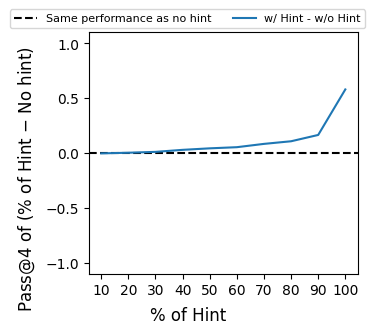

In [41]:
n_rows = 1
n_cols = 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3.0 * n_rows), layout="constrained")

ax = axes

ax.axhline(
    0.0,
    label="Same performance as no hint",
    color="black",
    linestyle="--",
)

ax.plot(
    x_range,
    pass_k_deltas,
    label="w/ Hint - w/o Hint"
)
ax.set_xticks(x_range)
ax.set_ylim(-1.1, 1.1)

fig.supylabel("Pass@4 of (% of Hint $-$ No hint)")
fig.supxlabel("% of Hint")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

plt.show()

In [ ]:
df = pd.DataFrame([])
for eval_name in tqdm(all_evals):
    curr_dir = os.path.join(data_dir, eval_name)
    key = eval_name.split("-")[-1]
    all_results.setdefault(key, dict())

    for sample_filename in os.listdir(os.path.join(curr_dir, "rollout/0")):
        sample_file = os.path.join(curr_dir, "rollout/0", sample_filename)
        sample_result = pd.read_json(path_or_buf=sample_file, lines=True)
        sample_result = sample_result.drop("prompt", axis=1)
        sample_result = sample_result.drop("completion", axis=1)
        sample_result["hint%"] = int(key) / 100.0

        df = pd.concat((df, sample_result), axis=0, join='outer', ignore_index=False, keys=None)

  0%|          | 0/11 [00:00<?, ?it/s]

In [73]:
df

,task_id,sample_idx,seqlen,prompt_len,head_version,tail_version,reward,hint%
0,1008,0,4334,104,-1,0,0,0
1,1008,1,2646,104,-1,0,0,0
2,1008,2,3199,104,-1,0,0,0
3,1008,3,1786,104,-1,0,0,0
4,1008,4,2541,104,-1,0,0,0
...,...,...,...,...,...,...,...,...
3,509,3,7510,630,-1,0,0,90
4,509,4,3428,630,-1,0,0,90
5,509,5,6491,630,-1,0,0,90
6,509,6,6869,630,-1,0,0,90


Qualifying (task, hint%) pairs: 1715
Qualifying tasks:               858
Always below p1:                860
Always above p2:                4


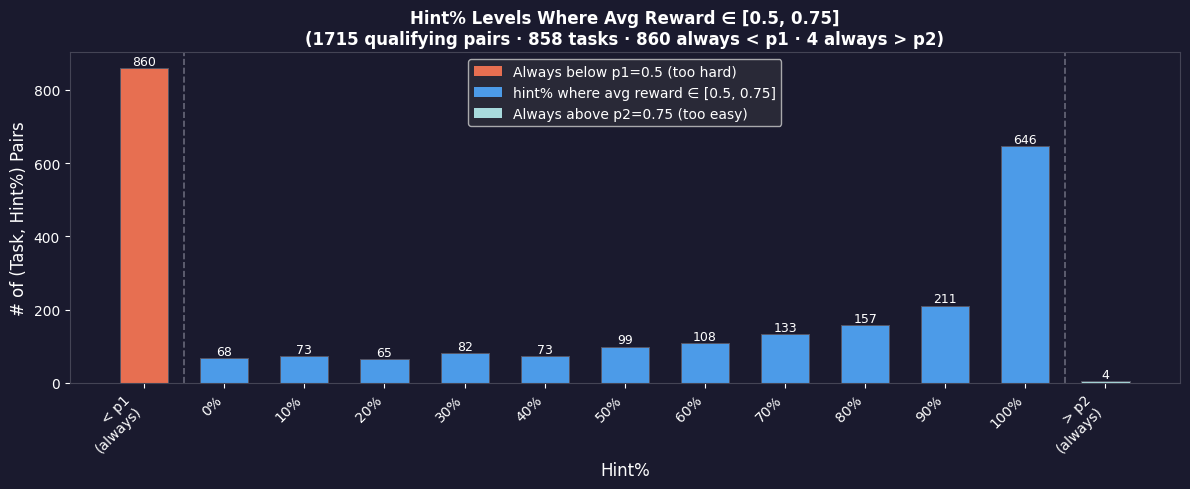

In [84]:
p1, p2 = 0.5, 0.75

# Step 1: Avg reward per (task_id, hint%)
task_hint_reward = df.groupby(["task_id", "hint%"])["reward"].mean().reset_index()
task_hint_reward.columns = ["task_id", "hint%", "avg_reward"]

# Step 2: All (task_id, hint%) pairs where avg reward ∈ [p1, p2]
in_range = task_hint_reward[
    (task_hint_reward["avg_reward"] >= p1) & (task_hint_reward["avg_reward"] <= p2)
]
qualifying_tasks = set(in_range["task_id"])

# Step 3: Classify never-in-range tasks
never_tasks = task_hint_reward[~task_hint_reward["task_id"].isin(qualifying_tasks)]
task_max_reward = never_tasks.groupby("task_id")["avg_reward"].max()
task_min_reward = never_tasks.groupby("task_id")["avg_reward"].min()
always_below_p1 = (task_max_reward < p1).sum()
always_above_p2 = (task_min_reward > p2).sum()

print(f"Qualifying (task, hint%) pairs: {len(in_range)}")
print(f"Qualifying tasks:               {len(qualifying_tasks)}")
print(f"Always below p1:                {always_below_p1}")
print(f"Always above p2:                {always_above_p2}")

# Step 4: Count ALL qualifying (task_id, hint%) pairs per hint% level
hint_counts = in_range["hint%"].value_counts().sort_index()
unique_hints = list(hint_counts.index)

bar_labels = ["< p1\n(always)"] + [f"{int(v)}%" for v in unique_hints] + ["> p2\n(always)"]
bar_values = [always_below_p1] + list(hint_counts.values) + [always_above_p2]
bar_colors = (
    ["#E76F51"]
    + ["#4C9BE8"] * len(unique_hints)
    + ["#A8DADC"]
)

x_pos = list(range(len(bar_labels)))

# Step 5: Plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x_pos, bar_values, width=0.6,
       color=bar_colors, edgecolor="#555566", linewidth=0.7)

for x, y in zip(x_pos, bar_values):
    ax.text(x, y + 0.3, str(y), ha="center", va="bottom", color="white", fontsize=9)

ax.axvline(x=0.5,                    color="#888899", linewidth=1.2, linestyle="--", alpha=0.7)
ax.axvline(x=len(bar_labels) - 1.5, color="#888899", linewidth=1.2, linestyle="--", alpha=0.7)

ax.set_xticks(x_pos)
ax.set_xticklabels(bar_labels, rotation=45, ha="right")
ax.set_xlabel("Hint%", fontsize=12)
ax.set_ylabel("# of (Task, Hint%) Pairs", fontsize=12)
ax.set_title(
    f"Hint% Levels Where Avg Reward ∈ [{p1}, {p2}]\n"
    f"({len(in_range)} qualifying pairs · {len(qualifying_tasks)} tasks · "
    f"{always_below_p1} always < p1 · {always_above_p2} always > p2)",
    fontsize=12, fontweight="bold"
)

legend_elements = [
    Patch(facecolor="#E76F51", label=f"Always below p1={p1} (too hard)"),
    Patch(facecolor="#4C9BE8", label=f"hint% where avg reward ∈ [{p1}, {p2}]"),
    Patch(facecolor="#A8DADC", label=f"Always above p2={p2} (too easy)"),
]
ax.legend(handles=legend_elements, facecolor="#2E2E3A", labelcolor="white", fontsize=10)

ax.set_facecolor("#1A1A2E")
fig.patch.set_facecolor("#1A1A2E")
ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.title.set_color("white")
for spine in ax.spines.values():
    spine.set_edgecolor("#444455")

plt.tight_layout()
plt.savefig("hint_distribution.png", dpi=150, bbox_inches="tight")
plt.show()